In [25]:
%pip install streamlit plotly

     ---------------------------------------- 9.1/9.1 MB 4.6 MB/s eta 0:00:00
     -------------------------------------- 795.4/795.4 kB 8.4 MB/s eta 0:00:00
     ------------------------------------- 208.6/208.6 kB 12.4 MB/s eta 0:00:00
     ---------------------------------------- 6.9/6.9 MB 8.2 MB/s eta 0:00:00
     ------------------------------------- 437.9/437.9 kB 13.8 MB/s eta 0:00:00
     ---------------------------------------- 27.5/27.5 MB 5.1 MB/s eta 0:00:00
     ---------------------------------------- 79.1/79.1 kB 4.6 MB/s eta 0:00:00
     ---------------------------------------- 62.8/62.8 kB 3.5 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
#Load the data
infra = pd.read_csv('infra_metrics.csv', parse_dates=['timestamp']).sort_values('timestamp')
rum = pd.read_csv('rum_data.csv', parse_dates=['timestamp']).sort_values('timestamp')
logs = pd.read_csv('system_logs.csv', parse_dates=['timestamp']).sort_values('timestamp')

#Merge Infrastructure and RUM data (The nearest Join)
merged_df = pd.merge_asof(rum, infra, on='timestamp', direction='backward')

merged_df.head()

,timestamp,action,response_time_ms,status_code,isp,region,node_id,cpu_usage,mem_usage,disk_io
0,2026-04-02 16:05:11.412332,Login,211.943549,200,Glo,Lagos,fintech-srv-01,42.483571,29.470970,28.225982
1,2026-04-02 16:10:11.412332,Transfer,275.871693,200,Glo,Lagos,fintech-srv-01,39.308678,26.019571,29.280694
2,2026-04-02 16:15:11.412332,Login,348.446235,200,MTN,Lagos,fintech-srv-01,43.238443,31.325427,40.311062
3,2026-04-02 16:20:11.412332,CheckBalance,250.330469,200,MTN,Lagos,fintech-srv-01,47.615149,27.603369,21.276734
4,2026-04-02 16:25:11.412332,Transfer,276.848646,200,Glo,Lagos,fintech-srv-01,38.829233,30.229046,22.721584


In [8]:
#Create an "Error Flag"
#if the transaction failed (500), 0 if it was successful (200)
merged_df['is_error'] = (merged_df['status_code'] == 500).astype(int)
merged_df.tail()

,timestamp,action,response_time_ms,status_code,isp,region,node_id,cpu_usage,mem_usage,disk_io,is_error
2011,2026-04-09 15:40:11.412332,Transfer,403.959248,500,MTN,Lagos,fintech-srv-01,36.186376,84.371219,21.125746,1
2012,2026-04-09 15:45:11.412332,Transfer,468.832383,200,MTN,Lagos,fintech-srv-01,36.154288,88.115190,22.980266,0
2013,2026-04-09 15:50:11.412332,Login,352.210182,200,Airtel,Lagos,fintech-srv-01,35.300484,86.549666,47.804898,0
2014,2026-04-09 15:55:11.412332,Login,318.513754,500,Airtel,Lagos,fintech-srv-01,44.147374,86.697152,21.306694,1
2015,2026-04-09 16:00:11.412332,CheckBalance,346.253686,500,Glo,Lagos,fintech-srv-01,39.030869,82.167546,28.434749,1


In [9]:
# check out infrastructure metric that drives the errors
correlation = merged_df[['response_time_ms', 'is_error', 'cpu_usage', 'mem_usage', 'disk_io']].corr()

print("Correlation with Errors:")
print(correlation['is_error'].sort_values(ascending=False))

Correlation with Errors:
is_error            1.000000
mem_usage           0.313979
response_time_ms    0.149312
cpu_usage           0.019255
disk_io             0.016999
Name: is_error, dtype: float64


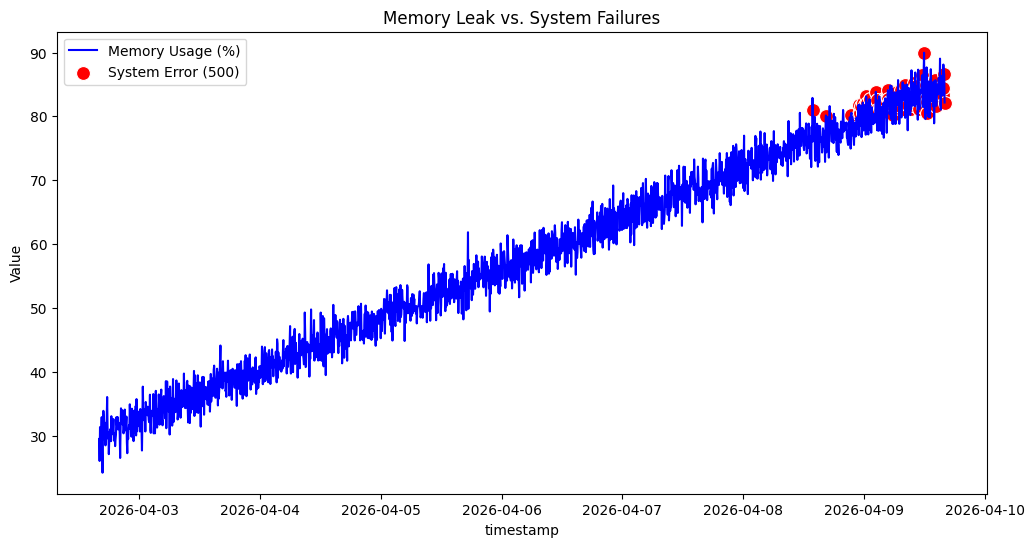

In [10]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=merged_df, x='timestamp', y='mem_usage', label='Memory Usage (%)', color='blue')
sns.scatterplot(data=merged_df[merged_df['is_error']==1], x='timestamp', y='mem_usage', color='red', label='System Error (500)', s=100)
plt.title('Memory Leak vs. System Failures')
plt.ylabel('Value')
plt.legend()
plt.show()

In [17]:
#Detect anomaly using IsolationForest
from sklearn.ensemble import IsolationForest


features = ['mem_usage', 'cpu_usage', 'response_time_ms']
X = merged_df[features]


In [19]:
#Instantiate model
model = IsolationForest(contamination=0.05, random_state=42) # 'contamination' is our guess of how much of the data is abnormal (e.g., 5%)

#Fit the model and predict (1 = normal, -1 = anomaly)
merged_df['anomaly_signal'] = model.fit_predict(X)
merged_df.head()

,timestamp,action,response_time_ms,status_code,isp,region,node_id,cpu_usage,mem_usage,disk_io,is_error,anomaly_signal
0,2026-04-02 16:05:11.412332,Login,211.943549,200,Glo,Lagos,fintech-srv-01,42.483571,29.470970,28.225982,0,1
1,2026-04-02 16:10:11.412332,Transfer,275.871693,200,Glo,Lagos,fintech-srv-01,39.308678,26.019571,29.280694,0,1
2,2026-04-02 16:15:11.412332,Login,348.446235,200,MTN,Lagos,fintech-srv-01,43.238443,31.325427,40.311062,0,1
3,2026-04-02 16:20:11.412332,CheckBalance,250.330469,200,MTN,Lagos,fintech-srv-01,47.615149,27.603369,21.276734,0,-1
4,2026-04-02 16:25:11.412332,Transfer,276.848646,200,Glo,Lagos,fintech-srv-01,38.829233,30.229046,22.721584,0,1


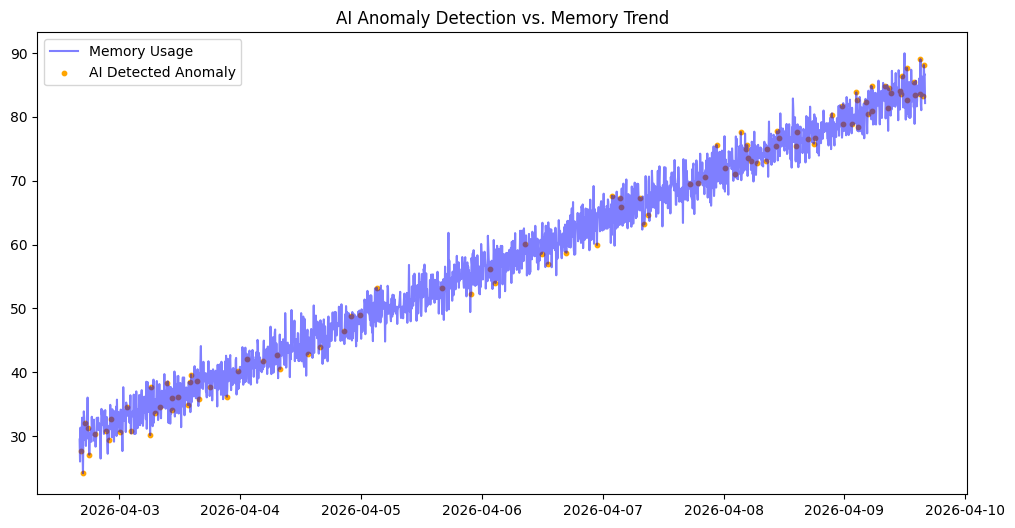

In [21]:
#Visualize the Anomaly Signals
plt.figure(figsize=(12, 6))
plt.plot(merged_df['timestamp'], merged_df['mem_usage'], color='blue', label='Memory Usage', alpha=0.5)
plt.scatter(merged_df[merged_df['anomaly_signal'] == -1]['timestamp'], 
            merged_df[merged_df['anomaly_signal'] == -1]['mem_usage'], 
            color='orange', label='AI Detected Anomaly', s=10)
plt.title('AI Anomaly Detection vs. Memory Trend')
plt.legend()
plt.show()

In [ ]:
#NLP Log Clustering
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

# Convert text logs into numbers (TF-IDF)
vectorizer = TfidfVectorizer(stop_words='english')
X_logs = vectorizer.fit_transform(logs['message'])

# Group logs into 3 clusters (Success, Warning, and Error)
kmeans = KMeans(n_clusters=3, random_state=42)
logs['cluster'] = kmeans.fit_predict(X_logs)


for i in range(3):
    sample_msg = logs[logs['cluster'] == i]['message'].iloc[0]
    print(f"Cluster {i} representative message: {sample_msg}")

Cluster 0 representative message: INFO: Transaction processed successfully
Cluster 1 representative message: WARN: High memory pressure detected in JVM
Cluster 2 representative message: ERROR: java.lang.OutOfMemoryError: Java heap space


In [ ]:
# Average memory per log cluster
analysis = pd.merge(logs, infra, on='timestamp')
print(analysis.groupby('cluster')['mem_usage'].mean())

cluster
0    44.997023
1    70.307816
2    83.069435
Name: mem_usage, dtype: float64


In [24]:
merged_df.to_csv('merged_observability_data.csv', index=False)